In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
%matplotlib inline

## Creating a linear layer

In [26]:
class Linear:
    def __init__(self, fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in,fan_out),generator=g) / fan_in**0.5 #This is Kaiming normalization to make sure that the pre-activation doesn't lead to vanishing weight updations and dead neurons
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out+=self.bias
        return self.out
    def parameters(self):
        return [self.weight] +([] if self.bias is None else [self.bias])


        

# Creating BatchNormalization in One Dimensions


In [149]:
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # affine parameters trained during backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers trained with a running momentum update
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self,x):
        if self.training:
            if x.ndim==2:
                dim=0
            elif x.ndim==3:
                dim=(0,1)
            xmean = x.mean(dim,keepdim=True) # Batch mean
            xvar = x.var(dim,keepdim=True, unbiased=True) # Batch Variance
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat +self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum)*self.running_var  + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]
        

## TanH layer (just an abstraction)

In [28]:
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
        
    

# Embedding Class

In [109]:
class Embedding:
    def __init__(self,num_embeddings,embedding_dim):
        # num_embeddings represents the number of classes and dim represents the higher dimension that you want to represent it in
        self.weight = torch.randn(num_embeddings,embedding_dim)
    def __call__(self,IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]
    

# Flatten Layer

In [101]:
class FlattenConsecutive:
    def __init__(self,n):
        self.n = n
    def __call__(self,x):
        B, T, C = x.shape
        x = x.view(B,T//self.n,C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    def parameters(self):
        return []

# Sequential Layer


In [49]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out =x
        return self.out
    def parameters(self):
        # get the parameters for all the layers and stretch them out into one long list
        return [p for layer in self.layers for p in layer.parameters()]

## Main Implementation

In [5]:
words = open('names.txt','r').read().splitlines()

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [78]:
def build_dataset(words):
    block_size = 8
    X,Y=[],[]
    for w in words:
        # print(w)
        context=[0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context),'--->',itos[ix])
            context= context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])#80 percent for training
Xdev,Ydev = build_dataset(words[n1:n2]) # 10 percent for dev testing
Xte,Yte = build_dataset(words[n2:]) # 10 percent for final testing

torch.Size([182437, 8]) torch.Size([182437])
torch.Size([22781, 8]) torch.Size([22781])
torch.Size([22928, 8]) torch.Size([22928])


In [79]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->',itos[y.item()])

........ ---> t
.......t ---> a
......ta ---> u
.....tau ---> r
....taur ---> e
...taure ---> n
..tauren ---> .
........ ---> s
.......s ---> u
......su ---> l
.....sul ---> e
....sule ---> m
...sulem ---> a
..sulema ---> n
.suleman ---> .
........ ---> z
.......z ---> e
......ze ---> r
.....zer ---> e
....zere ---> n


In [30]:
Xtr.shape, Xtr.dtype, Ytr.shape,Ytr.dtype

(torch.Size([182580, 3]), torch.int64, torch.Size([182580]), torch.int64)

In [31]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # move data & params to device
# Xtr = Xtr.to(device)
# Ytr = Ytr.to(device)
# C   = C.to(device)  # your embedding matrix

# # if you have custom layers/params list already on device, great.
# # otherwise ensure their tensors were created on `device` (as in our previous classes).

In [80]:
torch.manual_seed(42)

In [136]:
n_embed = 10 # Dimensionality of character space
n_hidden = 68 # Num of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)
vocab_size = len(itos.keys())
block_size = 8

In [162]:
C = torch.randn(vocab_size,n_embed)
model=Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2),Linear(n_embed*2, n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
])

In [163]:
model.layers

In [164]:
with torch.no_grad():
    model.layers[-1].weight *=0.1
    # layers[-1].weight *=1 # Make the last layer less confident about the wrong probabilities that it might output
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3 # The gain introduced by Kaiming in his paper for Tanh preactivation function

parameters =model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad =True

22397


In [165]:
# Optimizations step (same as before)
max_steps = 20000
batch_size = 32
lossi = []
ud =[]

In [166]:
for i in range(max_steps):
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb = Xtr[ix],Ytr[ix] # batch for X and Y

    # forward pass
    logits = model(Xb)
    # This was when we didn't create a class for embedding and flatenning
    # emb = C[Xb]
    # x = emb.view(emb.shape[0],-1) # concatenate the vectors in the embedding of context
    # This was when we were spelling out each layer instead of enclosing them into a container
    # x=Xb
    # for layer in layers:
    #     x =  layer(x)
    loss = F.cross_entropy(logits,Yb)

    # backward pass
    # for layer in model.layers:
    #     layer.out.retain_grad() # To retain the gradients of all intermediate layers (basically all layers) so that they can be understood?
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr = 0.1 if i<10000 else 0.01 # conditional learning rate
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 1000 ==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters]) # Mean answers what is the center of a distribution whereas, std answers what is the average spread or how faraway from the mean is the average spread, this gives us an idea of what the absolute average update is which can be used to generate a ratio against the std of data which would gives us an idea of how the updates change wrt to the data that passes through.
    # break
        # if i >= 1000:
    #     break # AFTER_DEBUG: would take out obviously to run full optimization

      0/  20000:3.2750
   1000/  20000:2.5466
   2000/  20000:2.5214
   3000/  20000:2.4659
   4000/  20000:2.3955
   5000/  20000:2.2551
   6000/  20000:2.2734
   7000/  20000:2.4907
   8000/  20000:2.3091
   9000/  20000:2.2279
  10000/  20000:2.4416
  11000/  20000:2.0032
  12000/  20000:2.0474
  13000/  20000:2.0295
  14000/  20000:1.8379
  15000/  20000:1.8898
  16000/  20000:2.3869
  17000/  20000:2.2346
  18000/  20000:1.8108
  19000/  20000:2.0330


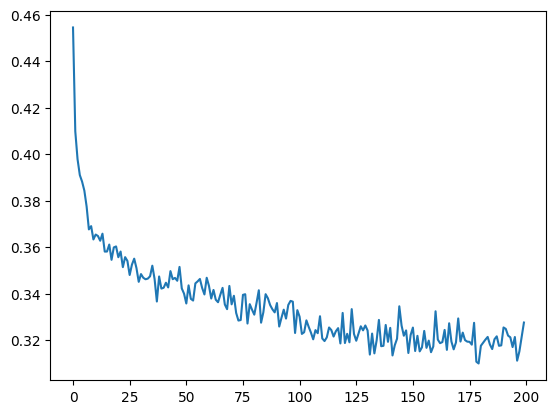

In [159]:
plt.plot(torch.tensor(lossi[:]).view(-1,100).mean(1))

In [72]:
for layer in model.layers:
    layer.training = False

In [160]:
@torch.no_grad()
def split_loss(split):
    x ,y ={
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.072965145111084
val 2.1142895221710205


In [ ]:
## Track
# Using non wave method -> train 2.392073392868042 val 2.38987135887146
# Wave Method -> train 2.072965145111084 val 2.1142895221710205

In [161]:
for _ in range(20):
    out = []
    context = [0]* block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0:
            break
    print(''.join(itos[i] for i in out))

C:\Users\goodt\AppData\Local\Temp\ipykernel_31928\3321303629.py:20: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  xvar = x.var(dim,keepdim=True, unbiased=True) # Batch Variance


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

C:\Users\goodt\AppData\Local\Temp\ipykernel_31928\3880257863.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print("layer %d (%10s) : mean %+.2f, std %.2f, saturated %.2f%% " % (i,layer.__class__.__name__,t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


layer 4 (      Tanh) : mean -0.05, std 0.72, saturated 11.00% 
layer 7 (      Tanh) : mean -0.03, std 0.70, saturated 7.00% 
layer 10 (      Tanh) : mean +0.04, std 0.67, saturated 6.00% 
layer 13 (      Tanh) : mean -0.01, std 0.65, saturated 1.00% 
layer 16 (      Tanh) : mean +0.08, std 0.61, saturated 1.00% 


Text(0.5, 1.0, 'activation distribution')

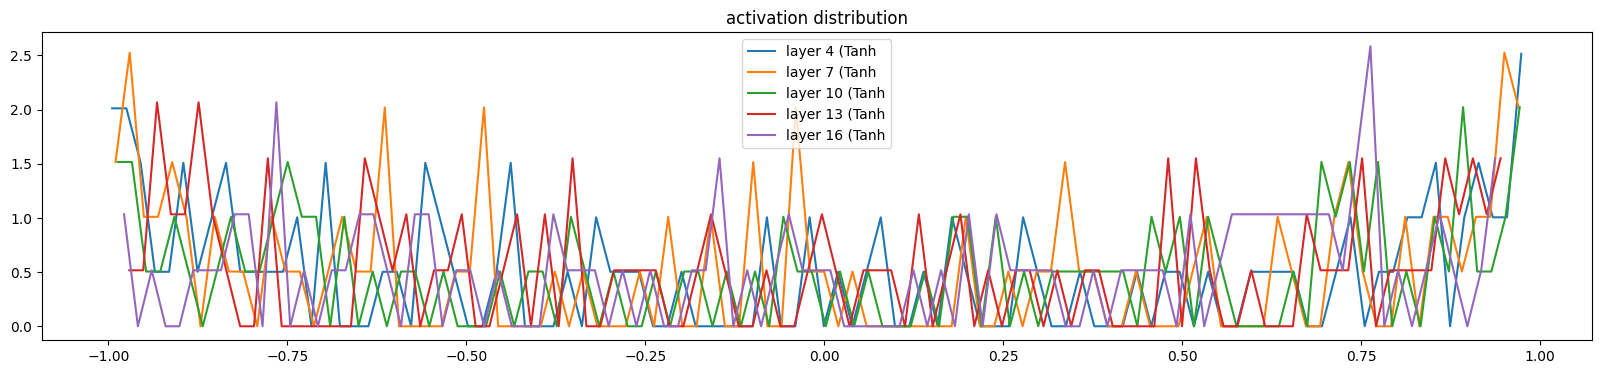

In [76]:
# Debug and Visualization
plt.figure(figsize=(20,4))
legends=[]
for i, layer in enumerate(model.layers):
    if isinstance(layer,Tanh):
        t = layer.out
        print("layer %d (%10s) : mean %+.2f, std %.2f, saturated %.2f%% " % (i,layer.__class__.__name__,t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy,hx = torch.histogram(t,density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

Here we make use of the kaiming normalization method to make sure that the weights are not vanishing. Weights vanish when the value output by preactivation layers are greater than or close to 1. Since Tanh is a "squashing function", all weights for values greater than one would be zero and since the gradient for Tanh is (1-sigma**2)(prev_grad) if prev_grad becomes zero the value of all grads from that point onwards would be zero. This would lead to a phenomenon called Dead Neuron. What Kaiming normalization does is to divide the output from the preactivation layer by the square root of the fan_in number. This would bring the mean and var respectively to close to zero and one, hence the output values now would be much more "stable". But since the values have to be close to one for Tanh to have a squashing effect if all values are small or less than 1 then the activation layer would not be able to bring in sufficient non-linearity, hence a gain is multiplied with the output values (there is a specific number for gain for each activation funcn) which would give suffience variance for the output values to bring in non-linearity via the activation function. 

layer 2 (      Tanh): mean -0.000000, std 3.078354e-03
layer 5 (      Tanh): mean -0.000000, std 2.610279e-03
layer 8 (      Tanh): mean -0.000000, std 2.395816e-03
layer 11 (      Tanh): mean +0.000000, std 2.243550e-03
layer 14 (      Tanh): mean -0.000000, std 2.428650e-03


Text(0.5, 1.0, 'gradient distribution')

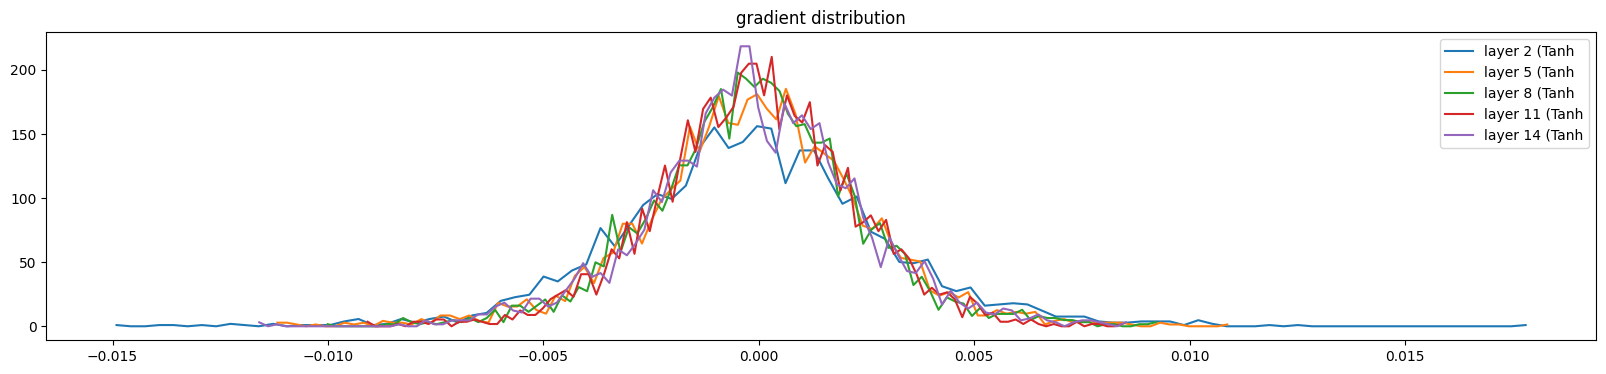

In [152]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

Change the value of gain to see how exploding gradients and vanishing gradients work and how the activation values are affected by them?

weight   (27, 10) | mean -0.000000 | std 8.437505e-03 | grad:data ratio 8.661834e-03
weight  (30, 100) | mean -0.000226 | std 7.831186e-03 | grad:data ratio 2.560652e-02
weight (100, 100) | mean +0.000125 | std 6.375120e-03 | grad:data ratio 3.800876e-02
weight (100, 100) | mean +0.000008 | std 5.697862e-03 | grad:data ratio 3.408038e-02
weight (100, 100) | mean -0.000073 | std 5.047881e-03 | grad:data ratio 3.023033e-02
weight (100, 100) | mean +0.000035 | std 5.016996e-03 | grad:data ratio 3.006581e-02
weight  (100, 27) | mean -0.000001 | std 1.029155e-02 | grad:data ratio 6.080851e-02


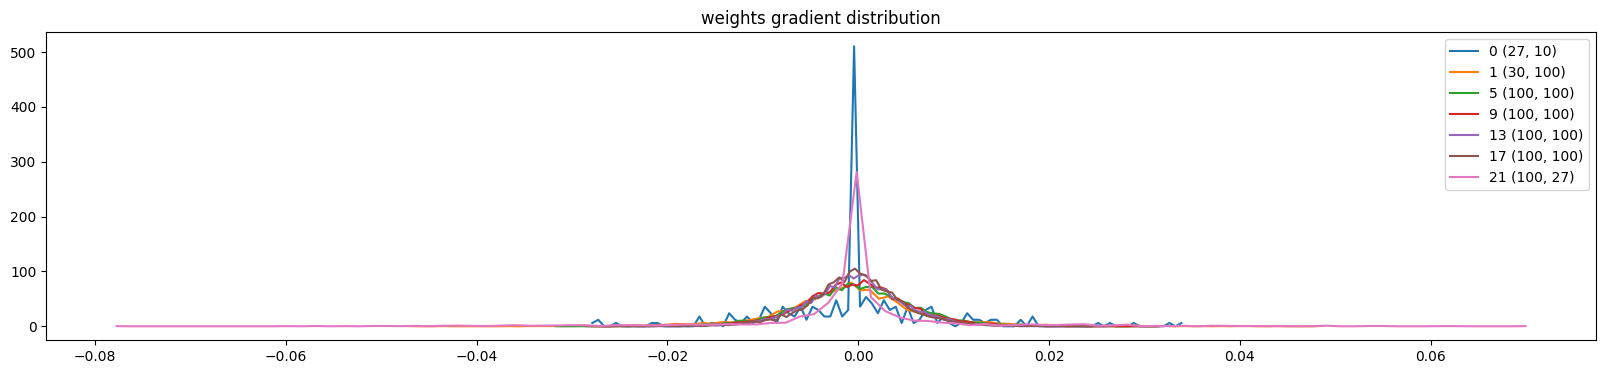

In [153]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

The weight gradient distribution is important to understand how large of an update happens at each step since update is lr*grad; Therefore if the grad/data ratio is too large then that means that the values are increasing at a much larger rate. This is something that usually resolves in multiple iterations of training.

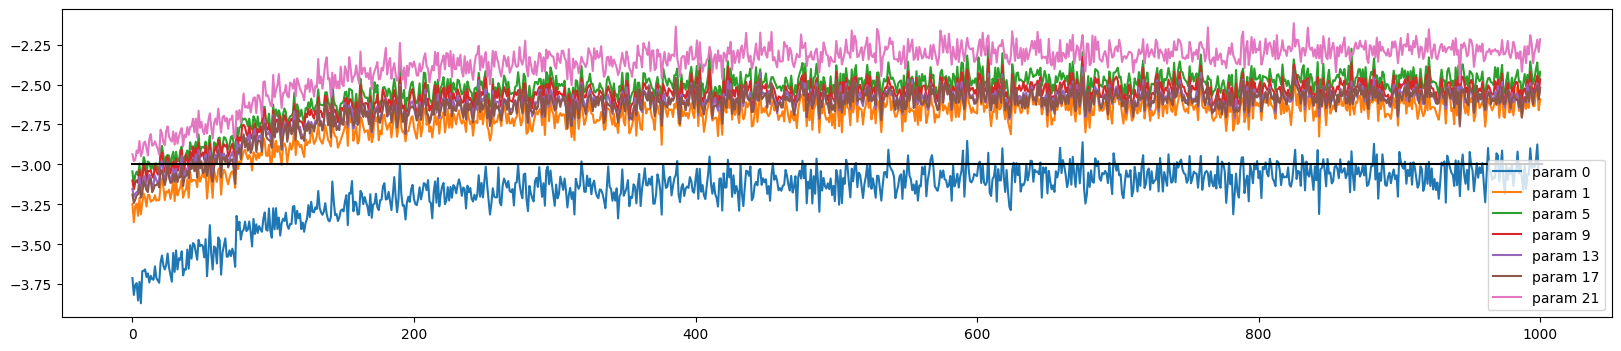

In [154]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

This lets us know how the weight updation progresses over each epoch. The black line indicates the somewhat average learning rate line aroung which most of the udpate lines should  be. If the lines are very high over the black line then we are learning too fast and if they are way lower than the black line then they are learning too slow.

If you are using batch normalization then kaiming normalization is not exactly required. Having it doesn't hurt and might seem a little beneficial. If kaiming is removed then the the activation values will not be exploding, neither will be exploding or vanishing gradients, neither will there be an issue in the gradient to data ratio but the update parameters might not be ideal. You might have to re-set the lr depending on how far off the the model is from expected learning rate.

## Scratchpad

In [151]:
ix = torch.randint(0,Xtr.shape[0],(4,))
Xb,Yb = Xtr[ix],Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  4,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  1]])

In [152]:
for i, layer in enumerate(model.layers):
    print(i,layer.__class__.__name__,tuple(layer.out.shape))

0 Embedding (4, 8, 10)
1 FlattenConsecutive (4, 4, 20)
2 Linear (4, 4, 68)
3 BatchNorm1d (4, 4, 68)
4 Tanh (4, 4, 68)
5 FlattenConsecutive (4, 2, 136)
6 Linear (4, 2, 68)
7 BatchNorm1d (4, 2, 68)
8 Tanh (4, 2, 68)
9 FlattenConsecutive (4, 136)
10 Linear (4, 68)
11 BatchNorm1d (4, 68)
12 Tanh (4, 68)
13 Linear (4, 27)


In [153]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [100]:
e = torch.randn(4,8,10)
explicit = torch.cat([e[:,::2,:],e[:,1::2,:]],dim=2)
explicit.shape
# flattening out every two character

torch.Size([4, 4, 20])

In [99]:
(e.view(4,4,20) == explicit).all()

tensor(True)

In [148]:
bne = torch.randn(4,4,200)
bne_mean = bne.mean((0,1),keepdim=True)
bne_mean.shape,bne.shape

(torch.Size([1, 1, 200]), torch.Size([4, 4, 200]))

In [ ]:
bne_mean.shape